# HI first-order harmonic decomposition -- TRM model: `fixed_PA42`

Measures the first-order harmonic radial term `s1 = V_rad(R)` from a MeerKAT
HI velocity field, ring by ring, holding the rotation curve fixed at the
3D-Barolo tilted-ring values. See `CLAUDE.md` in the project root for the
full specification this notebook and its two modules (`harmonic_fit.py`,
`harmonic_plots.py`) implement.

This notebook runs the pipeline for one TRM model: **`fixed_PA42`** (a
self-contained directory with its own `maps/` and ringlog). Other TRM models
found in this repo: TRM_paper.
Each gets its own generated notebook -- see `scripts/build_notebook.py`.

**Ring-radius convention.** The ringlog file inside the TRM model directory
(auto-discovered by `hf.find_ringlog`, filename varies by model) lists
`RAD(arcs)` uniformly spaced. `RAD` is the ring *center* (confirmed by the
project owner), so ring *i* spans `RAD - width/2 -> RAD + width/2`.

**Sign-convention caveat.** `s1 > 0` means outward motion *only if the near
side of the disc is known*; inclination alone is degenerate under `i -> -i`.
Every table and figure below carries `near_side_assumed = "UNRESOLVED"`.
Treat the sign of `s1` as a number to be interpreted with external
information (dust lanes, trailing-arm assumption), not a ready-made
inflow/outflow claim.

## Config

The one cell in this notebook you are expected to edit -- normally just
`TRM_DIR`, to point this notebook at a different TRM model directory.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import harmonic_fit as hf
import harmonic_plots as hp

repo_root = Path.cwd()
TRM_DIR = "fixed_PA42"  # which TRM model directory to run; see hf.discover_trm_models(repo_root)

trm_dir = repo_root / TRM_DIR
cfg = hf.Config(
    project_dir=trm_dir,
    maps_dir=trm_dir / "maps",
    ringlog_path=hf.find_ringlog(trm_dir),
    results_dir=trm_dir / "results",
)
cfg

Config(project_dir=PosixPath('/Users/24398082/projects/SM_harmonic_fit/fixed_PA42'), maps_dir=PosixPath('/Users/24398082/projects/SM_harmonic_fit/fixed_PA42/maps'), ringlog_path=PosixPath('/Users/24398082/projects/SM_harmonic_fit/fixed_PA42/B_rings_final.txt'), results_dir=PosixPath('/Users/24398082/projects/SM_harmonic_fit/fixed_PA42/results'), kpc_per_arcsec=0.32891247982574817, weighting_schemes=('uniform', 'sin2', 'invvar'), primary_weighting='sin2', model_terms=('c0', 's1'), sigma_floor_kms=5.0, sigma_artifact_floor_kms=0.5, pa_scan_halfwidth_deg=15.0, pa_scan_step_deg=0.25, vsys_scan_halfwidth_kms=20.0, vsys_scan_step_kms=0.5, s1_grid_halfwidth_kms=80.0, s1_grid_step_kms=0.5, n_bootstrap=2000, random_seed=42)

## Ring log and maps

Everything physical (`VROT`, `INC`, `P.A.`, `XPOS`, `YPOS`, `VSYS`, ring
radii, `kpc_per_arcsec`) comes from this TRM model's ringlog file
(`cfg.ringlog_path`, auto-discovered -- the filename is not fixed across
models). The moment maps are matched by globbing `maps/` for `*_1mom.fits` /
`*_2mom.fits` (data) and `*_local_1mom.fits` / `*_local_2mom.fits` (Barolo
model).

In [2]:
ringlog = hf.read_ringlog(cfg.ringlog_path)
mapset = hf.load_maps(cfg.maps_dir)

print(f"ringlog file = {cfg.ringlog_path.name}")
print(f"kpc_per_arcsec = {ringlog.meta['kpc_per_arcsec']:.5f}")
print(f"ring width = {ringlog.meta['ring_width_arcsec']:.2f} arcsec  (rad_convention: {ringlog.meta['rad_convention']})")
print(f"beam: BMAJ={mapset.bmaj_deg*3600:.2f}\" BMIN={mapset.bmin_deg*3600:.2f}\" BPA={mapset.bpa_deg:.1f} deg")
print(f"pixel scale: {mapset.pixscale_arcsec:.3f} arcsec/pix, map shape {mapset.shape}")

ringlog["RAD(arcs)", "VROT(km/s)", "INC(deg)", "P.A.(deg)", "VSYS(km/s)", "r_in_arcsec", "r_out_arcsec"]

ringlog file = B_rings_final.txt
kpc_per_arcsec = 0.32891
ring width = 9.70 arcsec  (rad_convention: RAD = ring center)
beam: BMAJ=19.52" BMIN=14.97" BPA=80.6 deg
pixel scale: 4.000 arcsec/pix, map shape (48, 48)


/Users/24398082/projects/SM_harmonic_fit/harmonic_fit.py:237: UserWarning: B_rings_final.txt: Barolo's own RAD(Kpc)/RAD(arcs) implies kpc_per_arcsec=0.33904, which differs from the adopted (Planck18, source-distance) value 0.32891 by 3.1%. Barolo's internal cosmology/distance assumption is unknown; the adopted value is used for every kpc conversion in this project regardless -- see CLAUDE.md Section 3.
  warnings.warn(


RAD(arcs),VROT(km/s),INC(deg),P.A.(deg),VSYS(km/s),r_in_arcsec,r_out_arcsec
float64,float64,float64,float64,float64,float64,float64
44.0,299.203,50.71,42.002,4678.026,39.15,48.85
53.7,297.697,50.71,42.002,4678.026,48.85,58.550000000000004
63.4,301.526,50.71,42.002,4678.026,58.55,68.25
73.1,309.458,50.71,42.002,4678.026,68.25,77.94999999999999


## Geometry and the receding-side check

`PA_math = PA_barolo + 90 deg` is only valid for an east-left image
(`CDELT1 < 0`, `origin='lower'`); this is asserted from the header, not
assumed. As a sanity check before fitting anything: within the outermost
ring, the *Barolo model* mom1 (not the data, so real non-circular motion
can't confuse the test) must be redshifted of `VSYS` on the
`cos(theta) > 0` (receding) side and blueshifted on the other.

In [3]:
cdelt1_sign = -1 if mapset.cdelt1_deg < 0 else (1 if mapset.cdelt1_deg > 0 else 0)
print(f"CDELT1 = {mapset.cdelt1_deg} deg/pix -> sign={cdelt1_sign} ({'east-left' if cdelt1_sign < 0 else 'UNCONFIRMED orientation'})")

outer_row = ringlog[-1]
xc0, yc0 = float(outer_row["XPOS(pix)"]), float(outer_row["YPOS(pix)"])
pa0, inc0, vsys0 = float(outer_row["P.A.(deg)"]), float(outer_row["INC(deg)"]), float(outer_row["VSYS(km/s)"])

R_pix0, theta0 = hf.make_geometry(mapset.shape, xc0, yc0, pa0, inc0, cdelt1_sign)
outer_mask0 = hf.ring_mask(R_pix0 * mapset.pixscale_arcsec, 0.0, float(outer_row["r_out_arcsec"]),
                            mapset.model_mom1, mapset.model_mom1)
mean_rec, mean_app = hf.assert_receding_side(theta0, mapset.model_mom1, vsys0, outer_mask0)
print(f"PASSED: mean(model-VSYS) receding={mean_rec:.2f} km/s, approaching={mean_app:.2f} km/s")

CDELT1 = -0.001111111138 deg/pix -> sign=-1 (east-left)
PASSED: mean(model-VSYS) receding=144.78 km/s, approaching=-146.03 km/s


## Run the pipeline

Fits `s1` per ring (all three weighting schemes, all three sides), runs the
PA/VSYS scans, and bootstraps the statistical error -- then writes
`results/ring_results.ecsv`, `results/maps.npz`, and `results/scans.npz`
under this TRM model's own directory. Takes a few seconds on this dataset.

In [4]:
results_table = hf.main(cfg)

[harmonic_fit] RAD convention: ring center (RAD +/- width/2)
[harmonic_fit] Ring bounds (arcsec):
    ring: 39.15 -- 48.85  (VROT=299.2 km/s, INC=50.71 deg, PA=42.00 deg)
    ring: 48.85 -- 58.55  (VROT=297.7 km/s, INC=50.71 deg, PA=42.00 deg)
    ring: 58.55 -- 68.25  (VROT=301.5 km/s, INC=50.71 deg, PA=42.00 deg)
    ring: 68.25 -- 77.95  (VROT=309.5 km/s, INC=50.71 deg, PA=42.00 deg)
[harmonic_fit] kpc_per_arcsec = 0.32891 (adopted, Planck18) vs. Barolo's own RAD(Kpc)/RAD(arcs) = 0.33904
[harmonic_fit] CDELT1 = -0.001111111138 deg/pix (sign=-1); pixel scale = 4.000 arcsec/pix
[harmonic_fit] beam = 19.516" x 14.973"; pixels_per_beam = 20.694
[harmonic_fit] Receding-side assertion PASSED: mean(model-VSYS)|receding=144.78, |approaching=-146.03


[harmonic_fit]   block_bootstrap_generic: redrew 1 degenerate resample(s) out of 2000 (rank-deficient design, n_cells=5)


[harmonic_fit] Wrote /Users/24398082/projects/SM_harmonic_fit/fixed_PA42/results/ring_results.ecsv
[harmonic_fit] Wrote /Users/24398082/projects/SM_harmonic_fit/fixed_PA42/results/maps.npz
[harmonic_fit] Wrote /Users/24398082/projects/SM_harmonic_fit/fixed_PA42/results/scans.npz

[harmonic_fit] Summary (side=both, primary weighting):
ring      r_in   r_out        s1   boot_lo   boot_hi        c0      chi2   n_eff
0        39.15   48.85     11.68      0.67     21.01     12.91     184.6     2.9
1        48.85   58.55      1.75     -4.11      6.29     13.91     345.3     5.4
2        58.55   68.25      0.58     -5.95      7.32     13.63     450.8     6.1
3        68.25   77.95     15.13      8.09     21.28      5.09     790.3     4.4


## Figure 1-2: convention checks

`fig_theta_map` shows `theta`, the approaching/receding split, and the
`w(theta)` weight map -- confirms the geometry and weighting look right
before trusting anything downstream. `fig_coverage` shows the azimuthal
coverage per ring with `L0`/`L1` printed on each panel: how much a `VSYS`
or `VROT` error would leak into `s1` for this ring's specific coverage gaps.

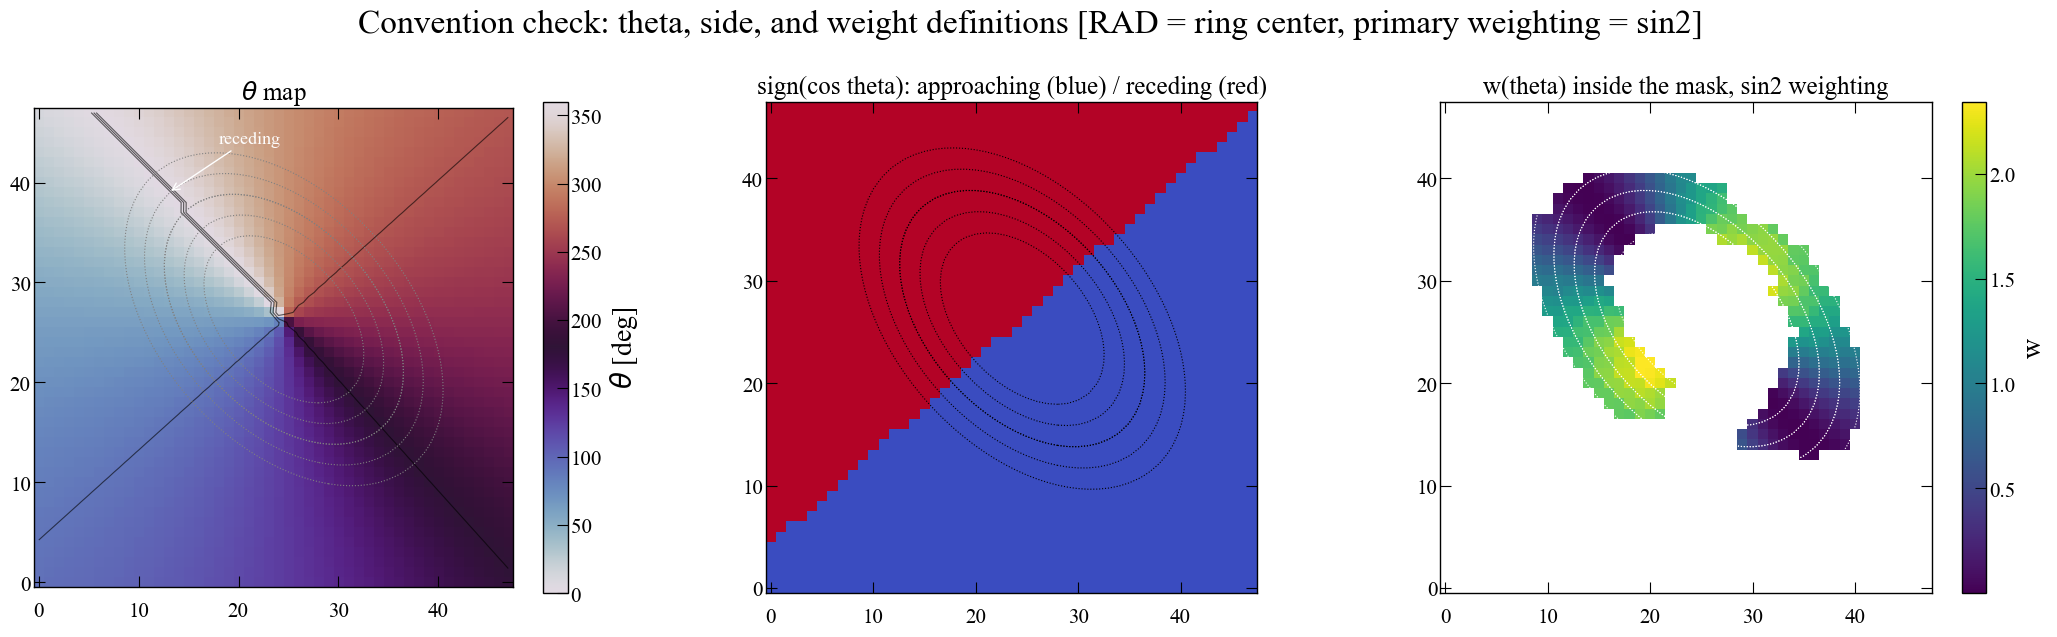

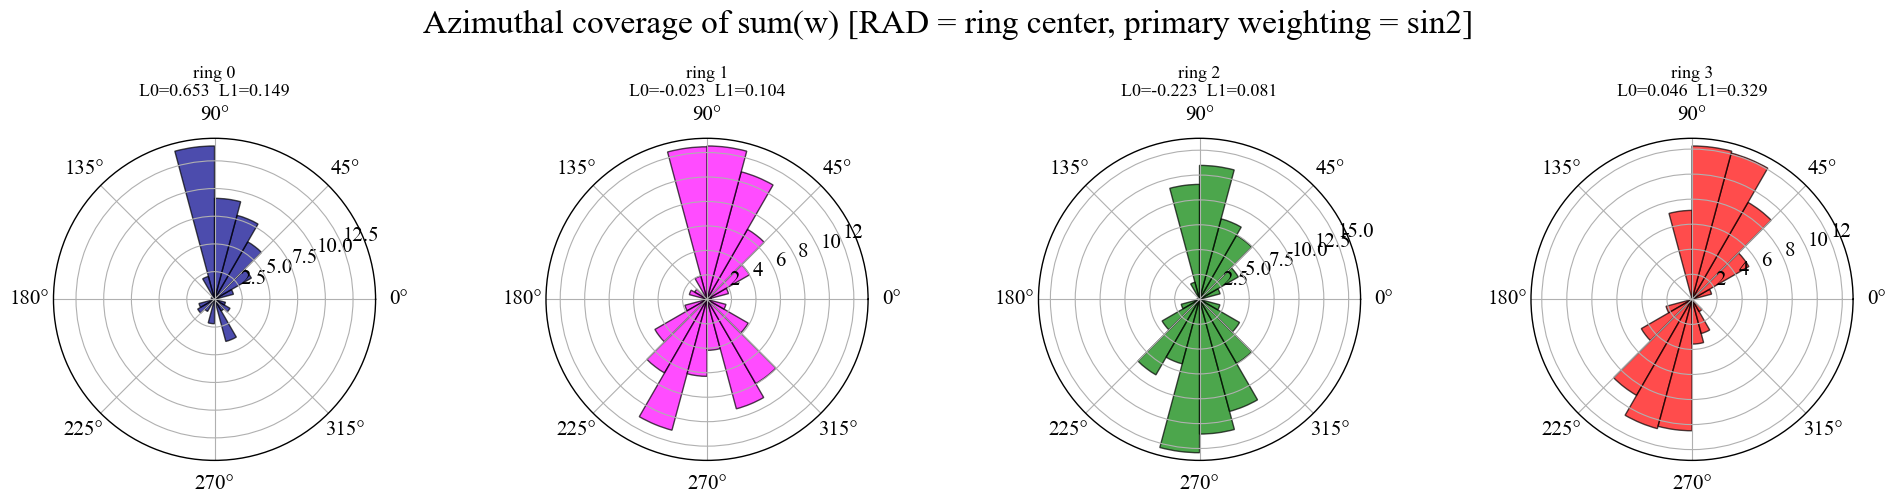

In [5]:
res = hp.load_results(cfg.results_dir)

hp.fig_theta_map(res)
hp.fig_coverage(res)
None

## `ring_results.ecsv`

In [6]:
res.table

ring_index,r_in_arcsec,r_out_arcsec,r_center_kpc,vrot_kms,inc_deg,pa0_deg,vsys_kms,xpos_pix,ypos_pix,side,weighting,s1,s1_formal_err,s1_boot_lo,s1_boot_med,s1_boot_hi,c0,c0_err,c2,s2,chi2,n_pix,n_eff,n_cells,pixels_per_beam,L0,L1,rms_residual,near_side_assumed,n_removed_quality_mask
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str11,str7,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,float64,float64,str10,int64
0,39.15,48.85,14.47214911233292,299.203,50.71,42.002,4678.026,24.539,26.31,both,uniform,9.090958685379046,4.561101656244533,-0.4919749882415462,9.396102108953702,18.184992516162758,7.0151489997146195,2.39642040951345,nan,nan,165.66359468333033,60,2.899407749868085,11,20.69388136343701,0.5034304734905647,0.24141332009880764,20.06649144438087,UNRESOLVED,24
0,39.15,48.85,14.47214911233292,299.203,50.71,42.002,4678.026,24.539,26.31,both,sin2,11.676463829894642,6.335295389948825,0.6747380104545273,10.76578859836492,21.011007844298845,12.907122052473087,5.016214583005315,nan,nan,184.58262408561635,60,2.899407749868085,11,20.69388136343701,0.6527339605253495,0.14861581920392578,21.137033992076258,UNRESOLVED,24
0,39.15,48.85,14.47214911233292,299.203,50.71,42.002,4678.026,24.539,26.31,both,invvar,8.120463139449363,2.9630259379520303,-7.465991603399471,8.494942644712463,22.410678584692242,7.0014529071395,1.489475191512566,nan,nan,165.7190454067864,60,2.899407749868085,11,20.69388136343701,0.40396986712833616,0.44058856757138704,20.07664718946722,UNRESOLVED,24
0,39.15,48.85,14.47214911233292,299.203,50.71,42.002,4678.026,24.539,26.31,approaching,uniform,29.998607437884043,7.1834811798273,23.21531231801779,29.572104822139117,39.309545236598176,12.76870314941308,3.766241918586559,nan,nan,30.974756671983336,22,1.0631161749516311,5,20.69388136343701,0.27263968515029163,0.20025964566175675,13.973224188174251,UNRESOLVED,24
0,39.15,48.85,14.47214911233292,299.203,50.71,42.002,4678.026,24.539,26.31,approaching,sin2,35.44287999164237,10.410449085569041,24.013902395607033,35.55210334591456,49.22349791007257,7.940771187389756,8.980687479745923,nan,nan,50.01106257007644,22,1.0631161749516311,5,20.69388136343701,0.5791728802281481,0.02200681192597831,15.014919261093262,UNRESOLVED,24
0,39.15,48.85,14.47214911233292,299.203,50.71,42.002,4678.026,24.539,26.31,approaching,invvar,34.36436341452605,4.1893636081809715,17.904466876550003,34.36436341452604,38.73042102099068,17.08572630339212,1.9966557906810567,nan,nan,25.328135211466925,22,1.0631161749516311,5,20.69388136343701,-0.003650853934202527,0.3983252374040394,15.069443403481314,UNRESOLVED,24
0,39.15,48.85,14.47214911233292,299.203,50.71,42.002,4678.026,24.539,26.31,receding,uniform,-4.286086409886974,5.921114201626497,-15.614125339247272,-4.944434467976978,5.217667442380219,5.785140136842256,3.098306375193571,nan,nan,51.8864720907461,38,1.8362915749164537,7,20.69388136343701,0.648985117216943,0.26736803199954706,16.9814530632353,UNRESOLVED,24
0,39.15,48.85,14.47214911233292,299.203,50.71,42.002,4678.026,24.539,26.31,receding,sin2,-7.860015183854397,7.702310573389747,-17.41336689045008,-7.359520807642378,-1.1236697434294243,18.56576596801374,5.649476155067094,nan,nan,110.59489160333705,38,1.8362915749164537,7,20.69388136343701,0.7074323501148421,0.24275947203839238,20.796660778154433,UNRESOLVED,24
0,39.15,48.85,14.47214911233292,299.203,50.71,42.002,4678.026,24.539,26.31,receding,invvar,-10.662173950523666,4.508751677474482,-18.6914358916575,-9.211260358794465,0.2003943697659377,1.2256228846951267,2.3838306696257,nan,nan,42.507085286481995,38,1.8362915749164537,7,20.69388136343701,0.764820618080928,0.4780026479667381,18.48074392852808,UNRESOLVED,24


## Figure 3: azimuthal comparison

Data, the Barolo model (through the same wedges and mask, so it carries the
same beam smearing), and the harmonic fit, all against azimuth. Where data
and Barolo diverge but data and the harmonic fit agree, that gap *is* the
`s1` detection, shown directly.

Error bars are the per-ring fit residual RMS divided by `sqrt(beams per
wedge)`, not the raw within-wedge pixel scatter -- at this dataset's beam
size a wedge typically holds well under one independent beam, so the
within-wedge scatter would mostly measure the model's own gradient across
the wedge (largest near the minor axis, exactly where the `s1` signal
lives) rather than measurement noise. Markers sit at each wedge's weighted
circular centroid, not its geometric center.

[fig_azimuthal_vlos] ring 0: max/min error bar ratio = 1.00
[fig_azimuthal_vlos] ring 1: max/min error bar ratio = 1.00
[fig_azimuthal_vlos] ring 2: max/min error bar ratio = 1.00
[fig_azimuthal_vlos] ring 3: max/min error bar ratio = 1.00


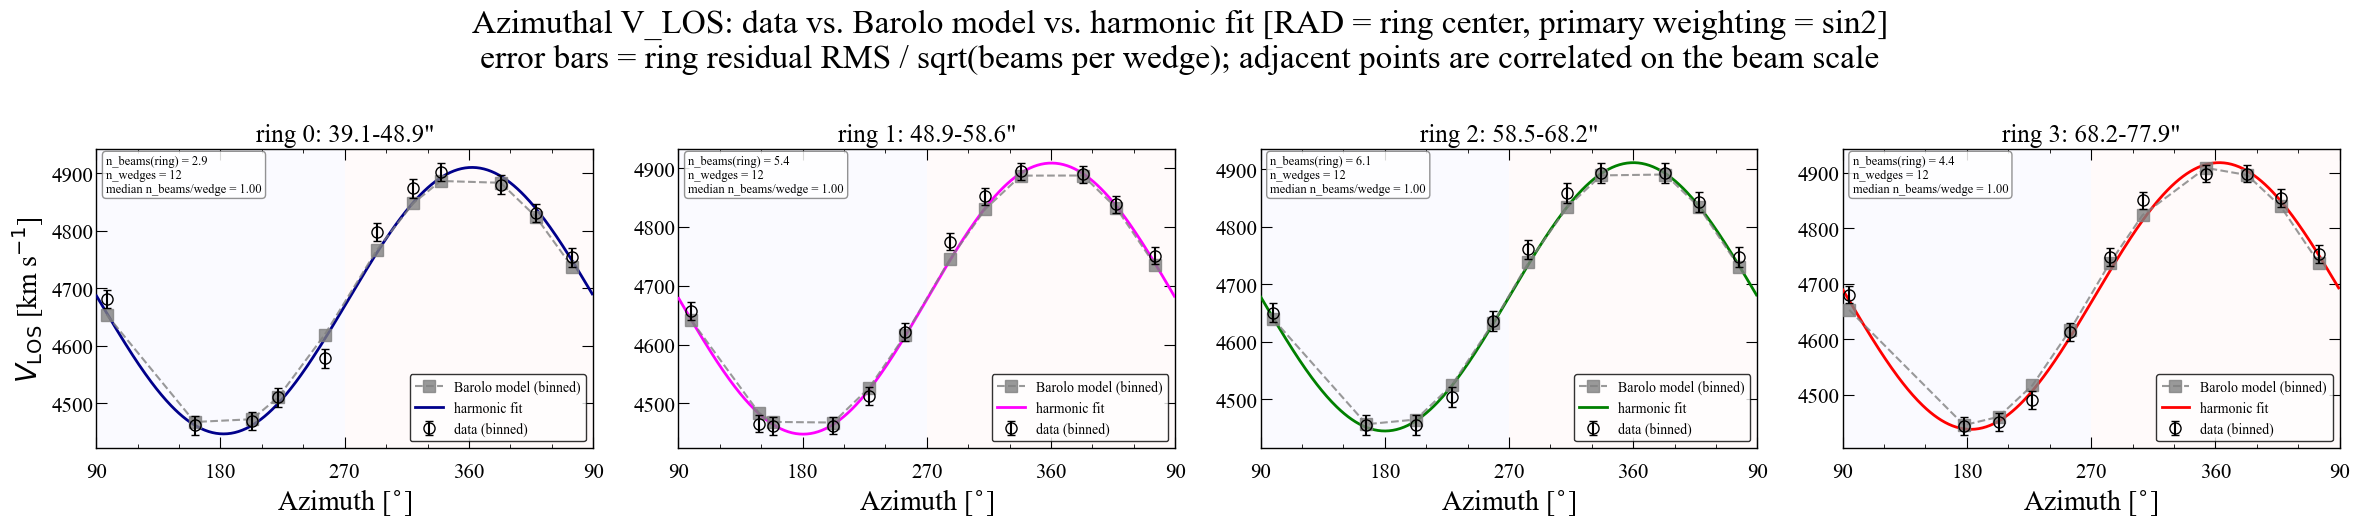

In [7]:
hp.fig_azimuthal_vlos(res, n_wedge=hp.AZIMUTHAL_N_WEDGE)
None

## Figure 4: pre-fit and post-fit residual maps

**The pre-fit panel (left) is the most important diagnostic in the
project.** Genuine axisymmetric radial motion appears as a clean dipole
aligned with the minor axis. A localised blob, a one-sided feature, or
something tracking tidal structure means a single `s1` per ring is the
wrong model -- worth ruling out given the group environment this target
sits in. The post-fit panel (right, after subtracting `s1*sin(theta)`)
should be structureless; any coherent pattern remaining is the argument for
enabling `c2, s2`.

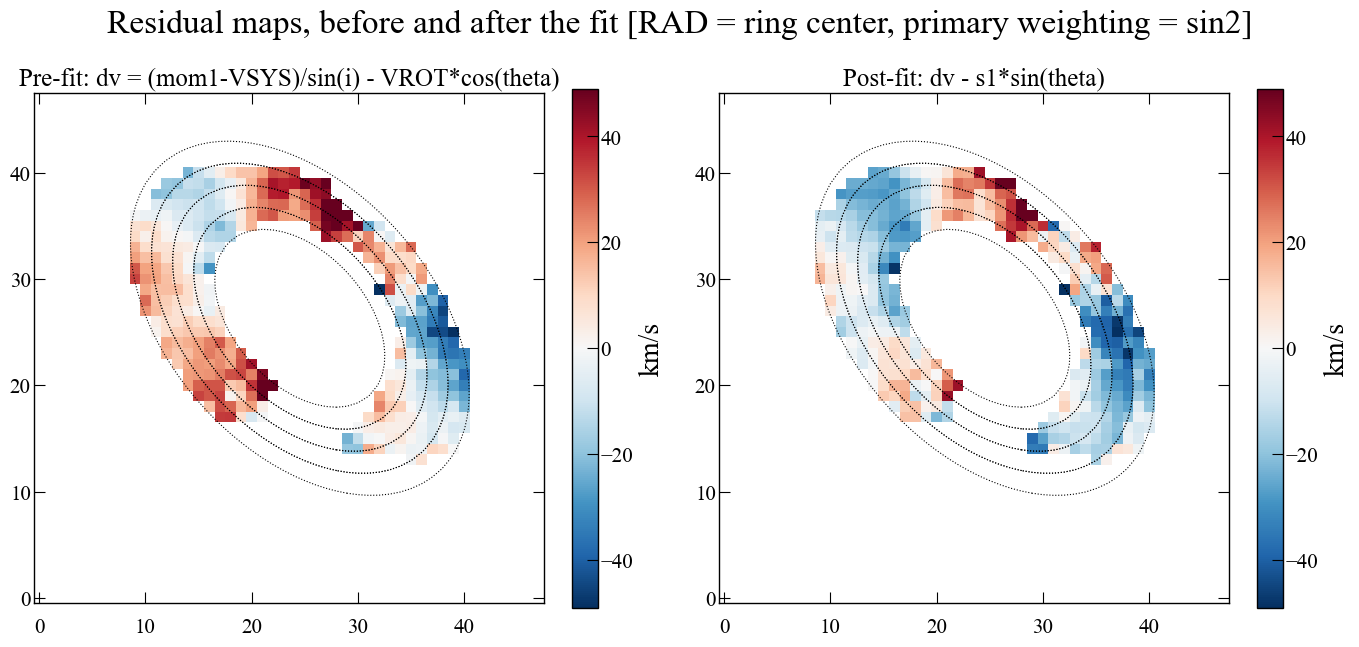

In [8]:
hp.fig_residual_maps(res)
None

## c0 toggle: fitting with and without the offset nuisance term

`c0` is a per-ring free offset that absorbs both `dVSYS / sin(i)` (an error
in the systemic velocity) and `V_z / tan(i)` (vertical motion) without
separating them (`CLAUDE.md` 2.5). `model_terms` is the single config knob
that controls which terms are fit (`s1` is always required; `c0`, and
optionally `c2`/`s2`, are toggled by including or omitting them) -- so
"fitting without c0" means rerunning `harmonic_fit.main()` with
`model_terms=("s1",)` instead of the default `("c0", "s1")`, into a second
`results_dir` so the two result sets don't overwrite each other.

Under perfectly symmetric azimuthal coverage `c0` and `s1` are orthogonal
(`L0 = 0`, `CLAUDE.md` 5.6), so removing `c0` should show up almost entirely
as a near-uniform, per-ring offset in the post-fit residual map -- not as a
shift in `s1`. The comparison below is the direct, on-this-data check of how
well that holds once blanked/masked pixels break the symmetry.

In [9]:
import dataclasses

cfg_no_c0 = dataclasses.replace(cfg, results_dir=cfg.results_dir / "no_c0", model_terms=("s1",))
results_table_no_c0 = hf.main(cfg_no_c0)

[harmonic_fit] RAD convention: ring center (RAD +/- width/2)
[harmonic_fit] Ring bounds (arcsec):
    ring: 39.15 -- 48.85  (VROT=299.2 km/s, INC=50.71 deg, PA=42.00 deg)
    ring: 48.85 -- 58.55  (VROT=297.7 km/s, INC=50.71 deg, PA=42.00 deg)
    ring: 58.55 -- 68.25  (VROT=301.5 km/s, INC=50.71 deg, PA=42.00 deg)
    ring: 68.25 -- 77.95  (VROT=309.5 km/s, INC=50.71 deg, PA=42.00 deg)
[harmonic_fit] kpc_per_arcsec = 0.32891 (adopted, Planck18) vs. Barolo's own RAD(Kpc)/RAD(arcs) = 0.33904
[harmonic_fit] CDELT1 = -0.001111111138 deg/pix (sign=-1); pixel scale = 4.000 arcsec/pix
[harmonic_fit] beam = 19.516" x 14.973"; pixels_per_beam = 20.694
[harmonic_fit] Receding-side assertion PASSED: mean(model-VSYS)|receding=144.78, |approaching=-146.03


/Users/24398082/projects/SM_harmonic_fit/harmonic_fit.py:237: UserWarning: B_rings_final.txt: Barolo's own RAD(Kpc)/RAD(arcs) implies kpc_per_arcsec=0.33904, which differs from the adopted (Planck18, source-distance) value 0.32891 by 3.1%. Barolo's internal cosmology/distance assumption is unknown; the adopted value is used for every kpc conversion in this project regardless -- see CLAUDE.md Section 3.
  warnings.warn(


[harmonic_fit] Wrote /Users/24398082/projects/SM_harmonic_fit/fixed_PA42/results/no_c0/ring_results.ecsv
[harmonic_fit] Wrote /Users/24398082/projects/SM_harmonic_fit/fixed_PA42/results/no_c0/maps.npz
[harmonic_fit] Wrote /Users/24398082/projects/SM_harmonic_fit/fixed_PA42/results/no_c0/scans.npz

[harmonic_fit] Summary (side=both, primary weighting):
ring      r_in   r_out        s1   boot_lo   boot_hi        c0      chi2   n_eff
0        39.15   48.85     20.10      7.36     27.90       nan     205.2     2.9
1        48.85   58.55      1.43     -7.32      8.94       nan     237.5     5.4
2        58.55   68.25     -2.47    -11.31      7.28       nan     336.3     6.1
3        68.25   77.95     15.37      8.80     21.25       nan     713.2     4.4


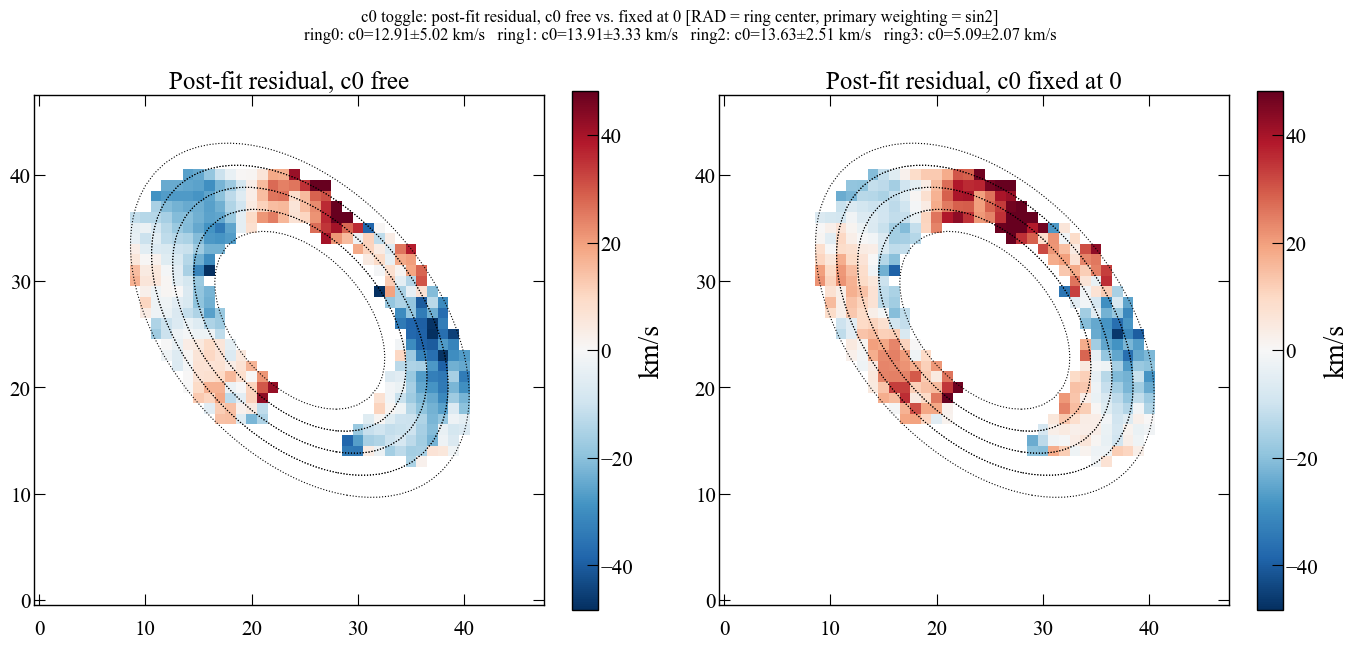

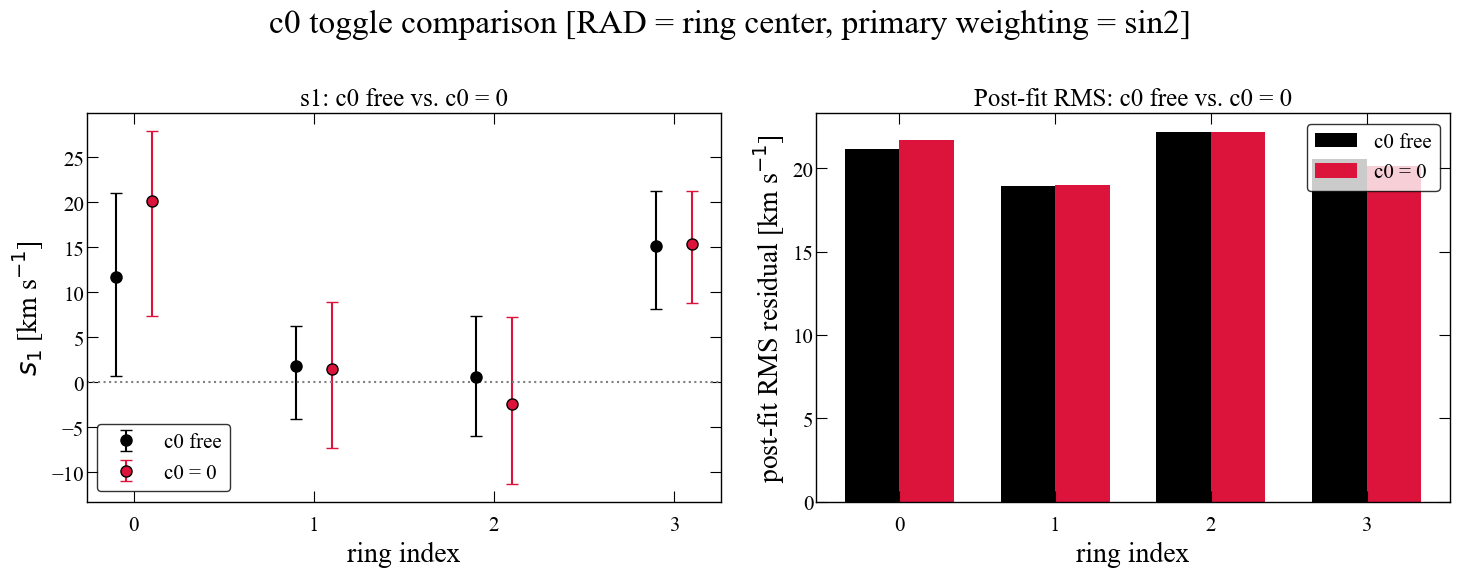

In [10]:
res_no_c0 = hp.load_results(cfg_no_c0.results_dir)

hp.fig_c0_toggle_residuals(res, res_no_c0)
hp.fig_c0_toggle_s1(res, res_no_c0)
None

If the left/right residual-map panels above differ mainly by a per-ring
constant shift (visually: same structure, offset in color), and the `s1`
points in the left comparison panel agree within their bootstrap error bars,
`c0` is doing exactly the job it's meant to -- soaking up an offset that
isn't `s1`. Any ring where `s1` shifts by more than its bootstrap width is a
direct, quantitative sign that this ring's masked coverage breaks the
`c0`/`s1` orthogonality (i.e. non-zero `L0`, figure 2) enough to matter.

## The V_rad-PA degeneracy: analytic derivation

A PA error `dPA` contributes a `sin(theta)` term to the residual -- the same
harmonic as the `s1` signal itself, so no weighting scheme can suppress it
(Section 5.6 of `CLAUDE.md`). The flat-sky approximation for this leak,
`s1_leak = -VROT * dPA[rad]`, is **not accurate at finite inclination**:
differentiating `make_geometry` shows a PA error does not shift `theta` by a
uniform amount once you deproject through `cos(inc)`:

```
dtheta/d(dPA) = -(cos(theta)^2/cos(inc) + cos(inc)*sin(theta)^2)  =  g(theta)
```

which ranges from `-1/cos(inc)` on the major axis to `-cos(inc)` on the
minor axis. Propagating this through the weighted `s1` estimator gives the
actual leakage slope:

```
K(scheme) = sum(w * g(theta) * sin(theta)**2) / sum(w * sin(theta)**2)
s1_leak   = VROT * dPA[rad] * K(scheme)
```

with closed forms for constant-`sigma` weighting (`ci = cos(inc)`):
`K_uniform = -(1/ci + 3*ci)/4`, `K_sin2 = -(1/ci + 5*ci)/6`. This is the
line overplotted on `fig_pa_degeneracy` below (via
`harmonic_fit.pa_degeneracy_slope`, computed numerically from each ring's
actual masked `theta`/`w`, not the closed form) -- and it is also the
inclination-corrected acceptance test in `harmonic_fit.py --selftest`
(test 2): if the numerical chi2 valley did not follow this line, the
deprojection would be wrong.

In [11]:
ci = np.cos(np.radians(res.table["inc_deg"][0]))
print(f"INC = {res.table['inc_deg'][0]:.3f} deg, cos(inc) = {ci:.4f}")
print(f"K_uniform (closed form) = {-(1/ci + 3*ci)/4:.3f}")
print(f"K_sin2 (closed form)    = {-(1/ci + 5*ci)/6:.3f}")
print()
print(f"{'ring':<6}{'VROT [km/s]':>14}{'K(sin2)':>10}{'slope [km/s/deg]':>20}")
for i in range(res.n_rings):
    theta = res.maps[f"ring{i}_theta"]
    mask = res.maps[f"ring{i}_ring_mask_both"]
    w = res.maps[f"ring{i}_weights_primary"]
    row = res.row(i)
    K = hf.pa_degeneracy_slope(theta[mask], w[mask], 1.0, row["inc_deg"])  # VROT=1 -> K itself
    slope_per_deg = row["vrot_kms"] * K * np.pi / 180.0
    print(f"{i:<6}{row['vrot_kms']:14.1f}{K:10.3f}{slope_per_deg:20.2f}")

INC = 50.710 deg, cos(inc) = 0.6332
K_uniform (closed form) = -0.870
K_sin2 (closed form)    = -0.791

ring     VROT [km/s]   K(sin2)    slope [km/s/deg]
0              299.2    -0.771               -4.03
1              297.7    -0.788               -4.09
2              301.5    -0.768               -4.04
3              309.5    -0.781               -4.22


## Figures 5-7: PA/VSYS degeneracy and s1 vs. PA offset

`fig_pa_degeneracy` doubles as an acceptance test for the geometry code: the
numerical chi2 valley should track the inclination-corrected analytic line
(just derived above) closely. `fig_vsys_degeneracy` is the contrast case --
expected to come out axis-aligned (untilted), confirming `VSYS` errors don't
leak into `s1` under symmetric coverage. `fig_s1_vs_pa` is the decisive
plot: if every ring nulls at the same PA offset, the signal is consistent
with a single PA error and the detection is not robust; if they null at
different offsets, no single PA error explains away the signal.

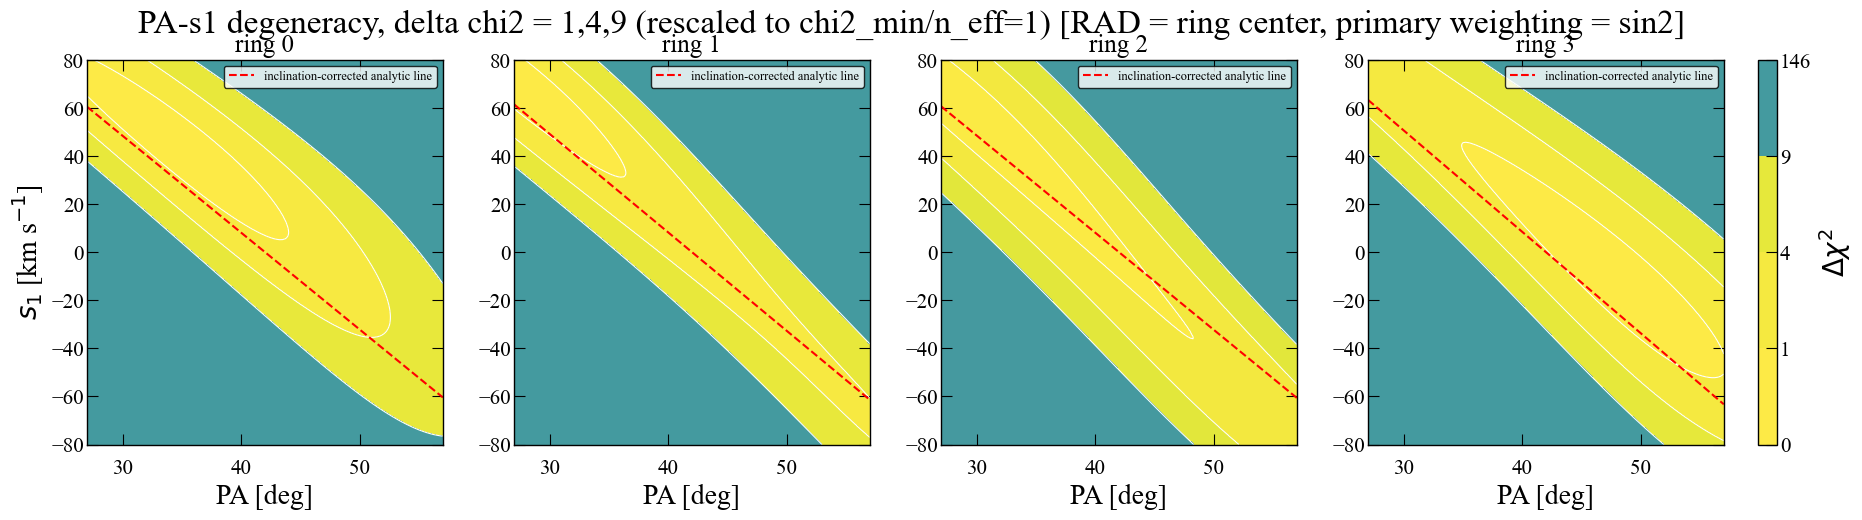

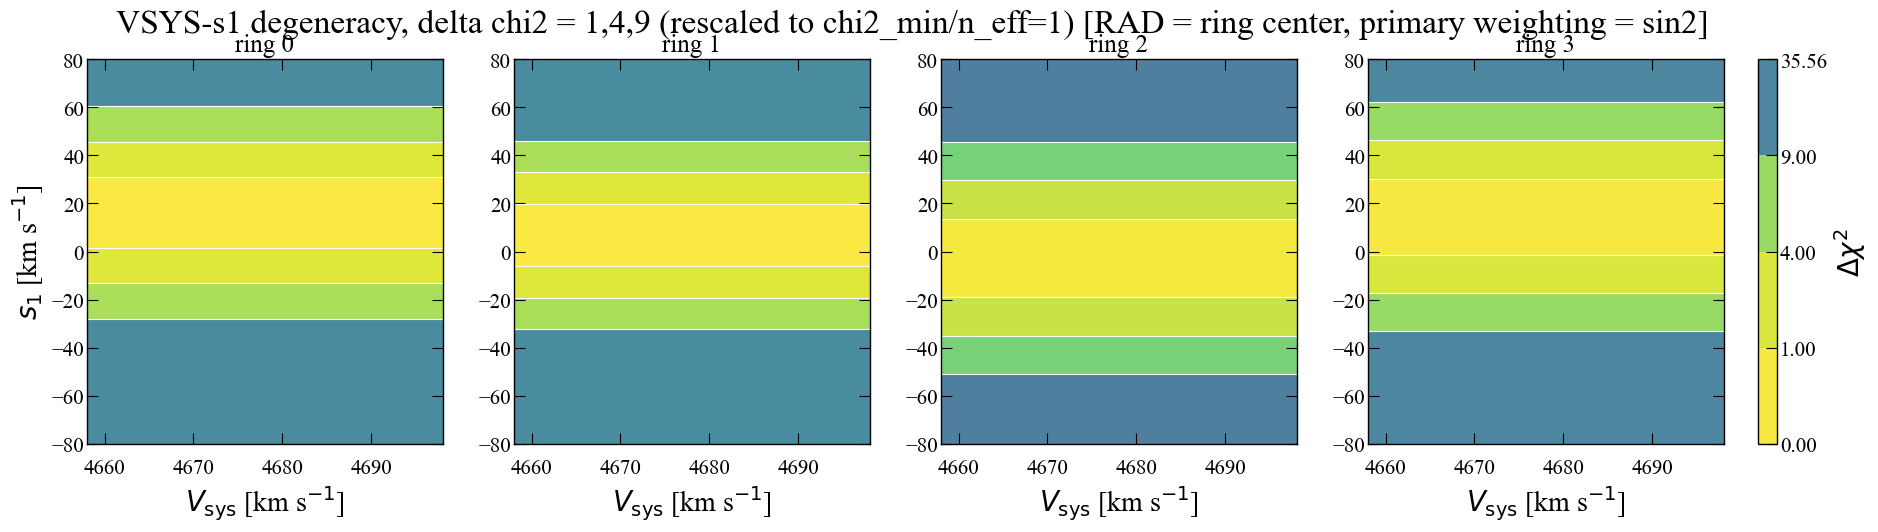

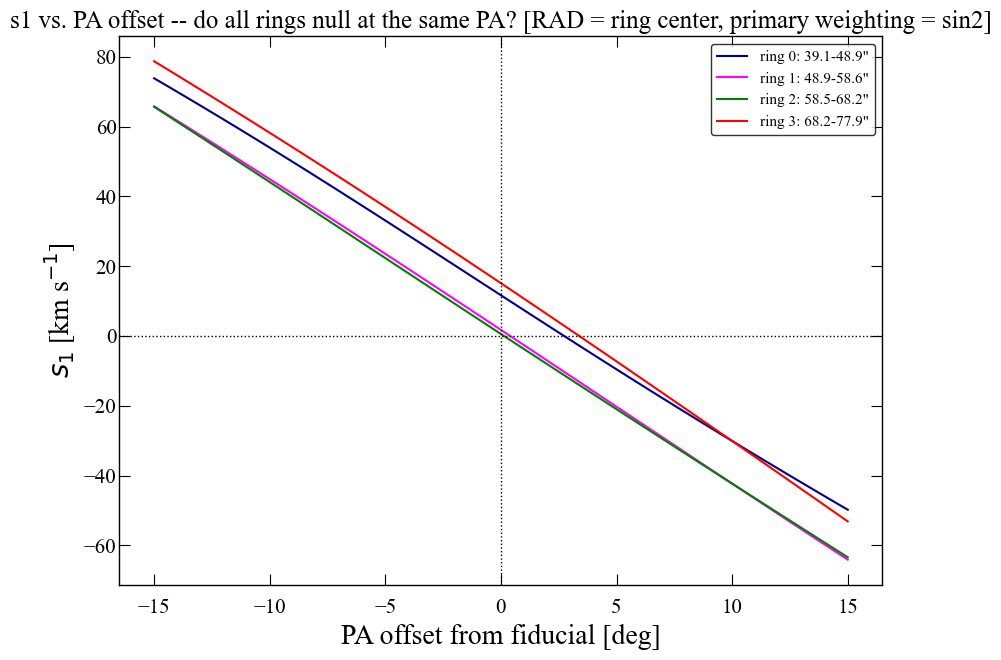

In [12]:
hp.fig_pa_degeneracy(res)
hp.fig_vsys_degeneracy(res)
hp.fig_s1_vs_pa(res)
None

## Figures 8-9: bootstrap and weighting-scheme comparison

The bootstrap interval is the quoted statistical error throughout this
project (the formal covariance from the fit assumes independent pixels,
which is false at 4" pixels under this beam). `fig_weighting_comparison`
shows whether `s1` is stable across `uniform`/`sin2`/`invvar`; if the
schemes disagree by more than the bootstrap width, that disagreement is
itself a result.

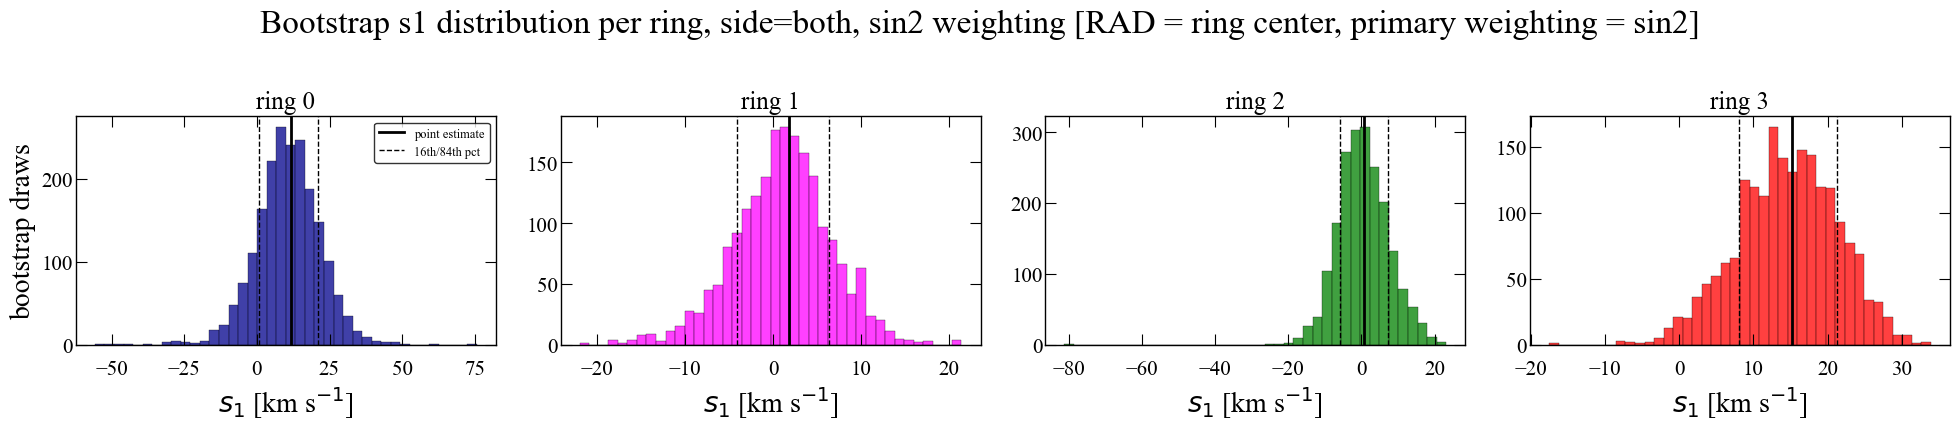

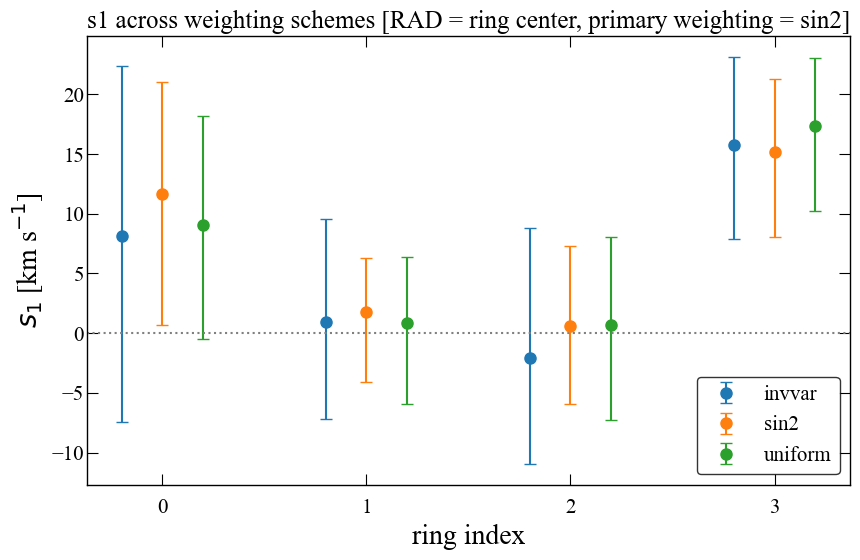

In [13]:
hp.fig_bootstrap(res)
hp.fig_weighting_comparison(res)
None

## Figure 10: V_rad(R) -- the headline result

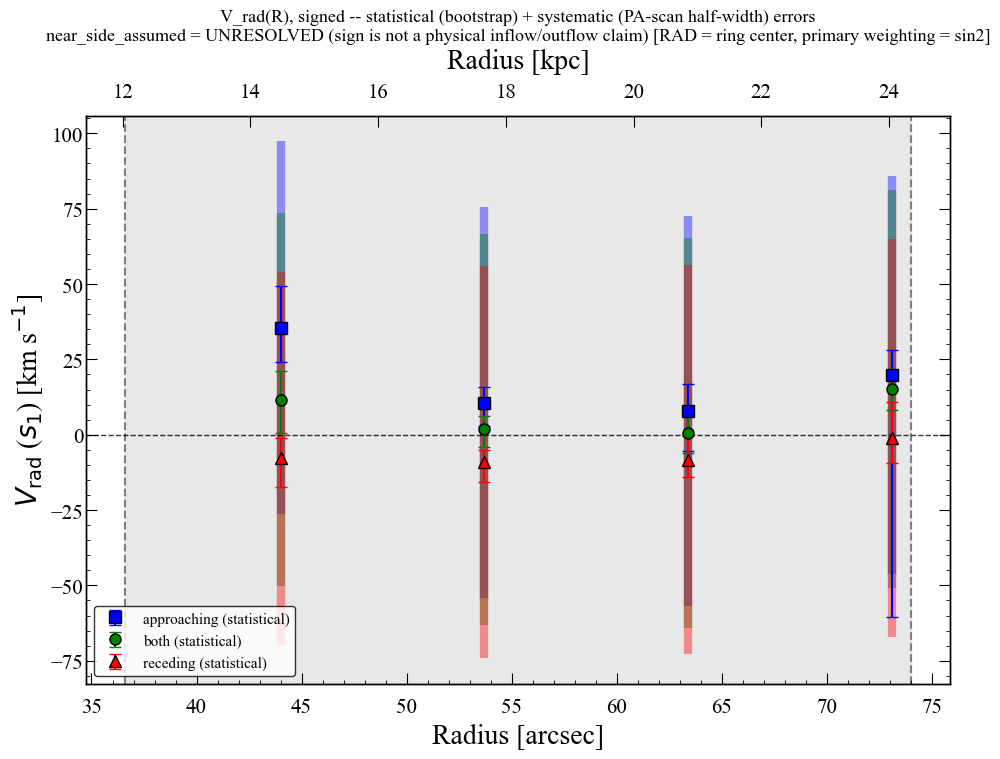

In [14]:
hp.fig_vrad_profile(res)
None

## Interpreting the sign of s1

`s1`'s sign only maps onto physical inflow/outflow given external
information about which side of the disc is nearer the observer -- Section
2.6 of `CLAUDE.md`. Given that information, the mapping is a short,
checkable derivation (recorded in full in `CLAUDE.md` Section 2.6.1):

`theta` increases counter-clockwise on the sky (a direct consequence of this
project's confirmed East-left, `CDELT1 < 0` orientation -- `make_geometry`
only ever rotates and positively stretches the pixel frame, never mirrors
it), and `theta = 0` is receding by construction. At `theta = 90 deg` (the
minor axis), pure rotation drops out (`cos(90 deg) = 0`), so the entire
residual there is the radial term: `v_los - VSYS = sin(i) * s1`. The near
side is, by definition, tilted toward the observer -- so outward motion
there blueshifts, inward motion redshifts.

**Given the near side is at `theta = +90 deg`** (the project owner's stated
determination for this galaxy, consistent with the observed clockwise
rotation on the sky -- the two aren't independent evidence, see `CLAUDE.md`
Section 2.6.1), true outward `V_rad = -s1`. The cell below applies that
mapping to *this* TRM model's own fitted `s1(R)`, whatever sign it came out
with -- read the printed table, don't assume the paper run's sign carries
over to a different TRM model. `near_side_assumed` in
`results/ring_results.ecsv` stays `"UNRESOLVED"`; this is a human
interpretation for the paper text, not something the pipeline itself
asserts.

In [15]:
primary = res.table[(res.table["side"] == "both") & (res.table["weighting"] == res.table.meta["primary_weighting"])]
primary = primary.copy()
primary.sort("ring_index")
print(f"{'ring':<6}{'r_center [kpc]':>16}{'s1 [km/s]':>12}{'outward V_rad = -s1 [km/s]':>28}")
for row in primary:
    print(f"{row['ring_index']:<6}{row['r_center_kpc']:16.2f}{row['s1']:12.2f}{-row['s1']:28.2f}")

ring    r_center [kpc]   s1 [km/s]  outward V_rad = -s1 [km/s]
0                14.47       11.68                      -11.68
1                17.66        1.75                       -1.75
2                20.85        0.58                       -0.58
3                24.04       15.13                      -15.13


## Closing summary: the error budget

- **Formal (covariance) errors** are reference only -- they assume
  independent pixels, false at 4" pixels under this beam. The **bootstrap**
  interval (figure 8) is the quoted statistical error.
- **`L0`/`L1`** (figure 2) measure leakage from `VSYS`/`VROT` errors into
  `s1` due to asymmetric azimuthal coverage; they are the quantitative
  justification for holding `VSYS` and `VROT` fixed rather than refitting
  them per ring.
- **PA is the one leak no weighting scheme can suppress** (figure 5): a PA
  error contributes a `sin(theta)` term, the same harmonic as the signal
  itself. Figure 7 (`s1` vs. PA offset) is the direct test of whether the
  detected `s1` survives a plausible PA error, ring by ring.
- **`VSYS` does not leak** under symmetric coverage (figure 6, by contrast
  with figure 5) -- any tilt seen there is a direct, quantitative measurement
  of this data's coverage asymmetry, not a generic property of the method.
- **The weighting-scheme comparison** (figure 9) is a robustness check, not
  a precision one: `sin2` is not claimed to be optimal, only less sensitive
  to the systematics (fixed-`VROT` error, beam smearing, warp) concentrated
  on the major axis.
- **The sign of `s1` is not a physical inflow/outflow claim from the
  pipeline alone** -- `near_side_assumed = "UNRESOLVED"` throughout, and the
  code never resolves it. Given the near side stated above
  (`theta = +90 deg`), true outward `V_rad = -s1` for this galaxy,
  regardless of which TRM model produced the `s1` estimate.
- Finally: this TRM model's `VROT` was fitted by 3D-Barolo with `VRAD` fixed
  at zero, so holding it fixed here is formally circular. Figure 5's PA scan
  is the quantitative handle on how much that circularity actually matters
  for the conclusion.